# LunarLander-v3 with DQN  
Saif Alomari  
March 1, 2026

In [16]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

from stable_baselines3 import DQN
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.vec_env import VecVideoRecorder

In [17]:
# Create the LunarLander environment
# This loads the physics simulator and prepares the RL environment
env = gym.make("LunarLander-v3")

# Print the observation space
# This tells us what the agent receives as input (state)
# For LunarLander, it is 8 continuous values
print("Observation space:", env.observation_space)

# Print the action space
# This tells us how many possible actions the agent can take
# For LunarLander, it is 4 discrete actions (0,1,2,3)
print("Action space:", env.action_space)

# Reset the environment to start a new episode
# seed=0 makes the starting condition reproducible
# obs = the initial state (8 numbers)
# info = extra environment information (not usually needed)
obs, info = env.reset(seed=0)

# Print the initial state of the lander
# These 8 numbers describe position, velocity, angle, etc.
print("Initial observation:", obs)

# Close the environment
# Always good practice to free resources when finished
env.close()

Observation space: Box([ -2.5        -2.5       -10.        -10.         -6.2831855 -10.
  -0.         -0.       ], [ 2.5        2.5       10.        10.         6.2831855 10.
  1.         1.       ], (8,), float32)
Action space: Discrete(4)
Initial observation: [ 0.00570612  1.3990337   0.5779653  -0.5282997  -0.0066053  -0.13091765
  0.          0.        ]


In [18]:
import gymnasium as gym
from stable_baselines3.common.monitor import Monitor

# Create the base environment
env = gym.make("LunarLander-v3")

# Wrap it with Monitor so it logs episode reward and episode length
# Monitor stores info like: total reward per episode, episode length, time, etc.
env = Monitor(env)

# Quick test run to confirm it works
obs, info = env.reset(seed=0)

done = False
total_reward = 0.0

while not done:
    action = env.action_space.sample()                 # random action (for testing)
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += float(reward)
    done = terminated or truncated

print("One random episode total reward:", total_reward)

env.close()

One random episode total reward: -131.0988750353316


It means:
- The lander played one full episode
- It used completely random actions
- The total accumulated reward during that episode was -81

Since the agent was acting randomly, it probably:
- Drifted
- Wasted fuel
- Crashed

So a negative reward is expected.

In [20]:
import os
from stable_baselines3.common.vec_env import DummyVecEnv, VecVideoRecorder

# Create folder to store videos
video_folder = "videos"
os.makedirs(video_folder, exist_ok=True)

# Function to create environment
def make_env():
    return gym.make("LunarLander-v3", render_mode="rgb_array")

# Wrap in DummyVecEnv (required by Stable Baselines)
env = DummyVecEnv([make_env])

# Wrap with video recorder
env = VecVideoRecorder(
    env,
    video_folder=video_folder,
    record_video_trigger=lambda x: x == 0,  # record first episode
    video_length=1000,
    name_prefix="random_lander"
)

In [22]:
from IPython.display import HTML
from base64 import b64encode
import glob

# Find the recorded video file
video_path = glob.glob("videos/*.mp4")[0]

mp4 = open(video_path, "rb").read()
data_url = "data:video/mp4;base64," + b64encode(mp4).decode()

HTML(f"""
<video width=600 controls>
  <source src="{data_url}" type="video/mp4">
</video>
""")

Step 5: Set up a training environment with Monitor

In [23]:
import os
import gymnasium as gym
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv

# Where to save logs and models
log_dir = "logs"
model_dir = "models"
os.makedirs(log_dir, exist_ok=True)
os.makedirs(model_dir, exist_ok=True)

def make_train_env():
    env = gym.make("LunarLander-v3")
    env = Monitor(env)  # logs episode reward/length
    return env

train_env = DummyVecEnv([make_train_env])

In [24]:
from stable_baselines3 import DQN

model = DQN(
    policy="MlpPolicy",
    env=train_env,
    learning_rate=1e-3,
    buffer_size=100_000,
    learning_starts=10_000,
    batch_size=64,
    gamma=0.99,
    tau=1.0,
    target_update_interval=1000,
    train_freq=4,
    gradient_steps=1,
    exploration_fraction=0.1,
    exploration_final_eps=0.02,
    verbose=1
)


Using cuda device


In [25]:
model.learn(total_timesteps=20_000)
model.save(os.path.join(model_dir, "dqn_lunarlander_smoketest"))

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 90       |
|    ep_rew_mean      | -163     |
|    exploration_rate | 0.824    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 15250    |
|    time_elapsed     | 0        |
|    total_timesteps  | 360      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 96.2     |
|    ep_rew_mean      | -153     |
|    exploration_rate | 0.623    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 14922    |
|    time_elapsed     | 0        |
|    total_timesteps  | 770      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 89.9     |
|    ep_rew_mean      | -164     |
|    exploration_rate | 0.471    |
| time/               |          |
|    episodes       

30 logging blocks total
Each block is a snapshot of training statistics at that moment.
It does NOT mean one episode.
It does NOT mean one timestep.
It means:
“Here is the average training performance over the last few episodes at this point in time.”


rollout/       

    ep_len_mean      | 156      |

    ep_rew_mean      | -185     |
    
    exploration_rate | 0.02     |

time/           
    episodes         | 120      |

    fps              | 1825     |

    time_elapsed     | 9        |

    total_timesteps  | 17295    |

train/         

    learning_rate    | 0.001    |

    loss             | 0.542    |

    n_updates        | 1823     |



Each block contains up to three sections:
A) rollout section: This describes what is happening inside the environment.
B) time section: This describes training progress.
C) train section: This only appears once learning actually starts.

- ep_len_mean: average episode length (how many steps until the episode ends), averaged over the last few episodes.
    Around 80 to 150 steps here means the lander usually ends the episode quickly (often by crashing or timing out early).
- ep_rew_mean: average total reward per episode, averaged over recent episodes.
    Your rewards are around -150 to -200, which is normal early training. It still crashes or lands badly.
- exploration_rate: epsilon value for epsilon-greedy.
    At the beginning it was high like 0.83, meaning lots of random actions.
    Then it dropped to 0.02, meaning mostly using what it has learned, with only 2 percent random actions.
- episodes: how many full games completed so far.
- fps: how fast training is running in steps per second.
- time_elapsed: seconds.
- total_timesteps: number of steps taken so far (this is what you set to 20,000 total).




======================================================================================================

Step 1: Set folders

In [26]:
import os

videos_dir = "videos_train"
logs_dir = "logs"
models_dir = "models"

os.makedirs(videos_dir, exist_ok=True)
os.makedirs(logs_dir, exist_ok=True)
os.makedirs(models_dir, exist_ok=True)

Step 2: Create the environment with RecordVideo + Monitor

In [27]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from stable_baselines3.common.monitor import Monitor

def episode_trigger(ep_num: int) -> bool:
    # Record at ep 0 (within first 50), then every 25 episodes
    return (ep_num % 25) == 0

def make_train_env():
    env = gym.make("LunarLander-v3", render_mode="rgb_array")

    # Record video every 25 episodes into videos_dir
    env = RecordVideo(
        env,
        video_folder=videos_dir,
        episode_trigger=episode_trigger,
        name_prefix="dqn_train"
    )

    # Track episode reward and length
    env = Monitor(env)
    return env

Step 3: Pick hyperparameters (and print them clearly)

In [28]:
hyperparams = {
    "policy": "MlpPolicy",

    # How fast the network learns each update
    "learning_rate": 5e-4,

    # How much experience to store
    "buffer_size": 200_000,

    # Do not start gradient updates until we have enough data
    "learning_starts": 10_000,

    # Mini batch size for replay
    "batch_size": 64,

    # Discount factor for future rewards
    "gamma": 0.99,

    # Target network update controls stability
    "target_update_interval": 1000,
    "tau": 1.0,

    # Update every 4 environment steps
    "train_freq": 4,
    "gradient_steps": 1,

    # Exploration schedule (epsilon greedy)
    "exploration_fraction": 0.2,
    "exploration_final_eps": 0.02,

    # Neural net size
    "policy_kwargs": dict(net_arch=[256, 256]),

    "verbose": 1,
}

for k, v in hyperparams.items():
    print(f"{k}: {v}")

policy: MlpPolicy
learning_rate: 0.0005
buffer_size: 200000
learning_starts: 10000
batch_size: 64
gamma: 0.99
target_update_interval: 1000
tau: 1.0
train_freq: 4
gradient_steps: 1
exploration_fraction: 0.2
exploration_final_eps: 0.02
policy_kwargs: {'net_arch': [256, 256]}
verbose: 1


Step 4: Create the model

In [29]:
from stable_baselines3 import DQN
from stable_baselines3.common.vec_env import DummyVecEnv

train_env = DummyVecEnv([make_train_env])

model = DQN(
    env=train_env,
    **hyperparams
)

Using cuda device


C:\Users\saifs\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\saifs\OneDrive\Desktop\2_ECE272B\HW4\videos_train folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


Step 5: Track episode rewards and stop after 600 episodes

In [30]:
from stable_baselines3.common.callbacks import BaseCallback

episode_rewards = []
episode_lengths = []

class StopAfterNEpisodesCallback(BaseCallback):
    def __init__(self, n_episodes: int):
        super().__init__()
        self.n_episodes = n_episodes

    def _on_step(self) -> bool:
        # Monitor puts episode info into info dict at episode end
        infos = self.locals.get("infos", [])
        for info in infos:
            if "episode" in info:
                episode_rewards.append(info["episode"]["r"])
                episode_lengths.append(info["episode"]["l"])

                if len(episode_rewards) % 25 == 0:
                    last100 = episode_rewards[-100:]
                    avg100 = sum(last100) / len(last100)
                    print(f"Episodes: {len(episode_rewards)} | last ep reward: {episode_rewards[-1]:.1f} | avg(last100): {avg100:.1f}")

                if len(episode_rewards) >= self.n_episodes:
                    return False
        return True

callback = StopAfterNEpisodesCallback(n_episodes=600)

Step 6: Train (run this)

In [31]:
model.learn(total_timesteps=5_000_000, callback=callback)

model_path = os.path.join(models_dir, "dqn_lunarlander_final")
model.save(model_path)
print("Saved model to:", model_path)
print("Total episodes collected:", len(episode_rewards))

----------------------------------
| rollout/            |          |
|    ep_len_mean      | 97.2     |
|    ep_rew_mean      | -260     |
|    exploration_rate | 1        |
| time/               |          |
|    episodes         | 4        |
|    fps              | 799      |
|    time_elapsed     | 0        |
|    total_timesteps  | 389      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 93.8     |
|    ep_rew_mean      | -178     |
|    exploration_rate | 0.999    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1409     |
|    time_elapsed     | 0        |
|    total_timesteps  | 750      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 99.7     |
|    ep_rew_mean      | -226     |
|    exploration_rate | 0.999    |
| time/               |          |
|    episodes       

Step 7: Plot reward per episode (for your report)

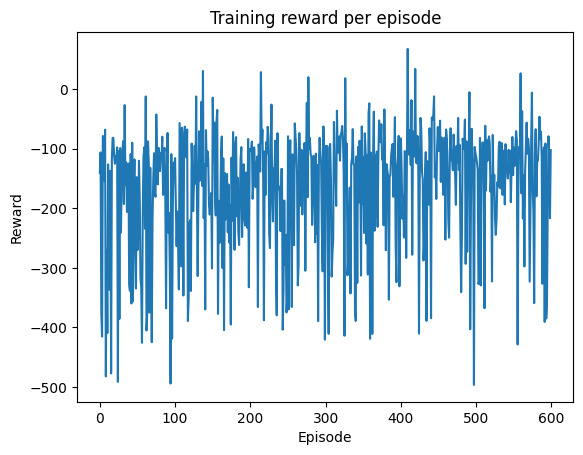

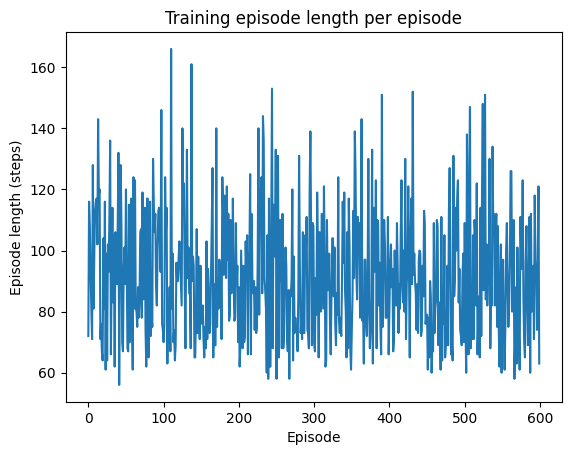

In [32]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(episode_rewards)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Training reward per episode")
plt.show()

plt.figure()
plt.plot(episode_lengths)
plt.xlabel("Episode")
plt.ylabel("Episode length (steps)")
plt.title("Training episode length per episode")
plt.show()

In [33]:
import numpy as np

def make_eval_env():
    env = gym.make("LunarLander-v3")  # no video needed for eval
    return env

eval_env = make_eval_env()

eval_rewards = []
for ep in range(100):
    obs, info = eval_env.reset(seed=1000 + ep)
    done = False
    total_r = 0.0

    while not done:
        action, _ = model.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_env.step(int(action))
        total_r += float(reward)
        done = terminated or truncated

    eval_rewards.append(total_r)

eval_env.close()

mean_r = float(np.mean(eval_rewards))
print("Eval mean reward over 100 episodes:", mean_r)

Eval mean reward over 100 episodes: -169.06908269250965


=================================================================================================

In [34]:
# Close any old environments to avoid video file locks
try:
    train_env.close()
except Exception:
    pass

del train_env

In [35]:
import os

run2_name = "run2"

videos_dir2 = f"videos_{run2_name}"
logs_dir2 = f"logs_{run2_name}"
models_dir2 = f"models_{run2_name}"

os.makedirs(videos_dir2, exist_ok=True)
os.makedirs(logs_dir2, exist_ok=True)
os.makedirs(models_dir2, exist_ok=True)

In [36]:
import gymnasium as gym
from gymnasium.wrappers import RecordVideo
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv

def episode_trigger(ep_num: int) -> bool:
    # record episode 0, 25, 50, ...
    return (ep_num % 25) == 0

def make_train_env_run2():
    env = gym.make("LunarLander-v3", render_mode="rgb_array")

    env = RecordVideo(
        env,
        video_folder=videos_dir2,
        episode_trigger=episode_trigger,
        name_prefix="dqn_train"
    )

    env = Monitor(env)
    return env

train_env = DummyVecEnv([make_train_env_run2])

C:\Users\saifs\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\gymnasium\wrappers\rendering.py:293: UserWarning: WARN: Overwriting existing videos at c:\Users\saifs\OneDrive\Desktop\2_ECE272B\HW4\videos_run2 folder (try specifying a different `video_folder` for the `RecordVideo` wrapper if this is not desired)
  logger.warn(


In [37]:
hyperparams2 = {
    "policy": "MlpPolicy",

    # Learning
    "learning_rate": 1e-3,

    # Replay
    "buffer_size": 300_000,
    "learning_starts": 5_000,
    "batch_size": 128,

    # RL
    "gamma": 0.99,

    # Target network updates
    "target_update_interval": 500,
    "tau": 1.0,

    # Train schedule
    "train_freq": 4,
    "gradient_steps": 1,

    # Exploration (this is the big one)
    "exploration_fraction": 0.30,
    "exploration_final_eps": 0.05,

    # Network size
    "policy_kwargs": dict(net_arch=[256, 256]),

    "verbose": 1,
}

for k, v in hyperparams2.items():
    print(f"{k}: {v}")

policy: MlpPolicy
learning_rate: 0.001
buffer_size: 300000
learning_starts: 5000
batch_size: 128
gamma: 0.99
target_update_interval: 500
tau: 1.0
train_freq: 4
gradient_steps: 1
exploration_fraction: 0.3
exploration_final_eps: 0.05
policy_kwargs: {'net_arch': [256, 256]}
verbose: 1


In [38]:
from stable_baselines3 import DQN

model2 = DQN(
    env=train_env,
    tensorboard_log=logs_dir2,
    **hyperparams2
)

Using cuda device


In [39]:
from stable_baselines3.common.callbacks import BaseCallback

episode_rewards2 = []
episode_lengths2 = []

class StopAfterNEpisodesCallback(BaseCallback):
    def __init__(self, n_episodes: int):
        super().__init__()
        self.n_episodes = n_episodes

    def _on_step(self) -> bool:
        infos = self.locals.get("infos", [])
        for info in infos:
            if "episode" in info:
                episode_rewards2.append(info["episode"]["r"])
                episode_lengths2.append(info["episode"]["l"])

                # Print progress every 25 eps
                if len(episode_rewards2) % 25 == 0:
                    last100 = episode_rewards2[-100:]
                    avg100 = sum(last100) / len(last100)
                    print(
                        f"Episodes: {len(episode_rewards2)} | "
                        f"last ep reward: {episode_rewards2[-1]:.1f} | "
                        f"avg(last100): {avg100:.1f}"
                    )

                # Stop condition
                if len(episode_rewards2) >= self.n_episodes:
                    return False
        return True

callback2 = StopAfterNEpisodesCallback(n_episodes=2000)

In [40]:
total_timesteps_run2 = 600_000

model2.learn(total_timesteps=total_timesteps_run2, callback=callback2)

model2_path = os.path.join(models_dir2, "dqn_lunarlander_run2")
model2.save(model2_path)

print("Saved model to:", model2_path)
print("Total episodes collected:", len(episode_rewards2))

Logging to logs_run2\DQN_1
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 99.2     |
|    ep_rew_mean      | -276     |
|    exploration_rate | 0.998    |
| time/               |          |
|    episodes         | 4        |
|    fps              | 700      |
|    time_elapsed     | 0        |
|    total_timesteps  | 397      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 97.4     |
|    ep_rew_mean      | -245     |
|    exploration_rate | 0.996    |
| time/               |          |
|    episodes         | 8        |
|    fps              | 1259     |
|    time_elapsed     | 0        |
|    total_timesteps  | 779      |
----------------------------------
----------------------------------
| rollout/            |          |
|    ep_len_mean      | 91.7     |
|    ep_rew_mean      | -215     |
|    exploration_rate | 0.994    |
| time/               |     

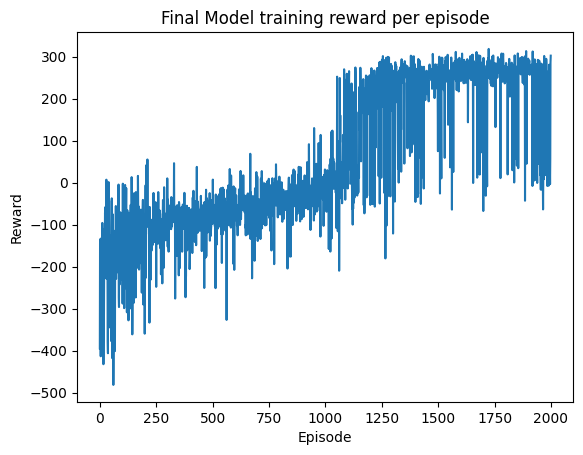

In [42]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(episode_rewards2)
plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Final Model training reward per episode")
plt.show()

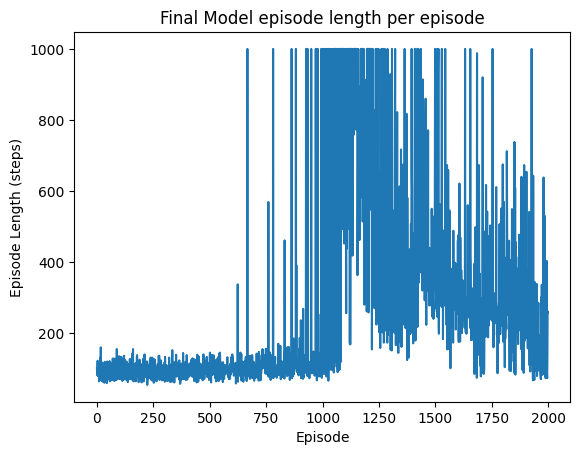

In [43]:
plt.figure()
plt.plot(episode_lengths2)
plt.xlabel("Episode")
plt.ylabel("Episode Length (steps)")
plt.title("Final Model episode length per episode")
plt.show()

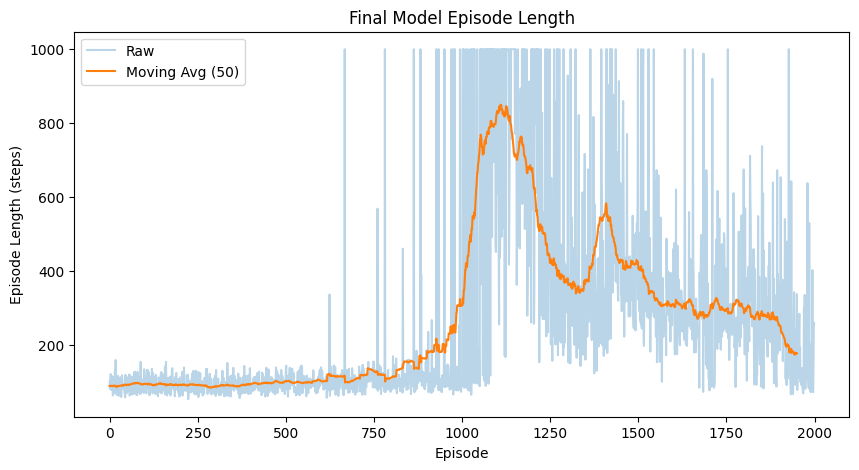

In [44]:
import numpy as np

def moving_average(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10,5))
plt.plot(episode_lengths2, alpha=0.3, label="Raw")
plt.plot(moving_average(episode_lengths2, 50), label="Moving Avg (50)")
plt.xlabel("Episode")
plt.ylabel("Episode Length (steps)")
plt.title("Final Model Episode Length")
plt.legend()
plt.show()

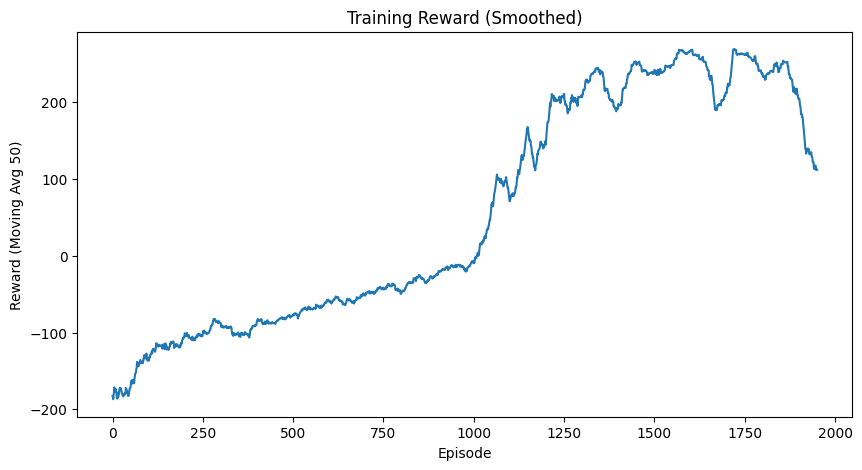

In [46]:
plt.figure(figsize=(10,5))
plt.plot(moving_average(episode_rewards2, 50))
plt.xlabel("Episode")
plt.ylabel("Reward (Moving Avg 50)")
plt.title("Training Reward (Smoothed)")
plt.show()

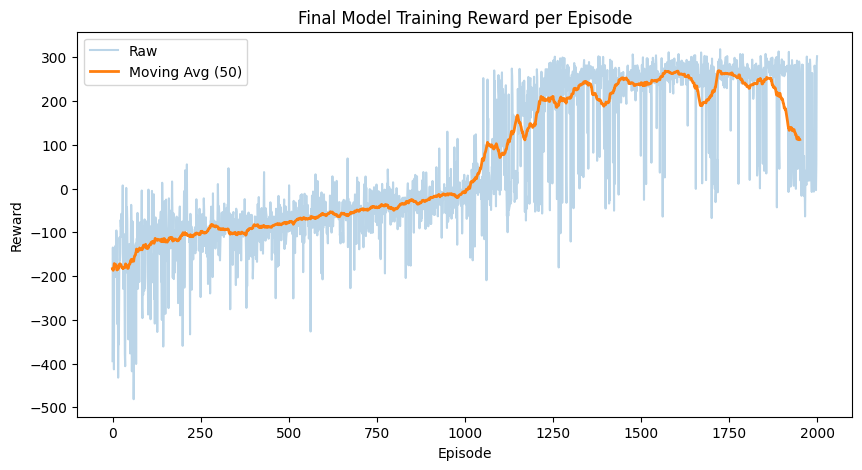

In [47]:
import numpy as np
import matplotlib.pyplot as plt

def moving_average(data, window=50):
    return np.convolve(data, np.ones(window)/window, mode='valid')

plt.figure(figsize=(10,5))

# Raw reward (faint)
plt.plot(episode_rewards2, alpha=0.3, label="Raw")

# Smoothed reward
plt.plot(moving_average(episode_rewards2, 50), 
         label="Moving Avg (50)", 
         linewidth=2)

plt.xlabel("Episode")
plt.ylabel("Reward")
plt.title("Final Model Training Reward per Episode")
plt.legend()
plt.show()

In [48]:
import gymnasium as gym
import numpy as np

eval_env = gym.make("LunarLander-v3")

eval_rewards = []
eval_lengths = []

for ep in range(100):
    obs, info = eval_env.reset(seed=1000 + ep)
    done = False
    total_reward = 0
    steps = 0

    while not done:
        action, _ = model2.predict(obs, deterministic=True)
        obs, reward, terminated, truncated, info = eval_env.step(int(action))
        total_reward += reward
        steps += 1
        done = terminated or truncated

    eval_rewards.append(total_reward)
    eval_lengths.append(steps)

eval_env.close()

mean_reward = np.mean(eval_rewards)
mean_length = np.mean(eval_lengths)

print("Mean reward over 100 episodes:", mean_reward)
print("Mean episode length over 100 episodes:", mean_length)

Mean reward over 100 episodes: 206.46195669177192
Mean episode length over 100 episodes: 183.35


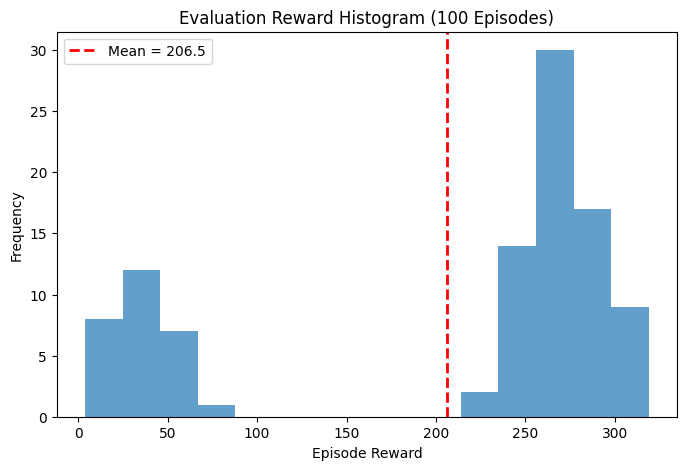

In [49]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(eval_rewards, bins=15, alpha=0.7)
plt.axvline(mean_reward, color='red', linestyle='dashed', linewidth=2,
            label=f"Mean = {mean_reward:.1f}")
plt.xlabel("Episode Reward")
plt.ylabel("Frequency")
plt.title("Evaluation Reward Histogram (100 Episodes)")
plt.legend()
plt.show()

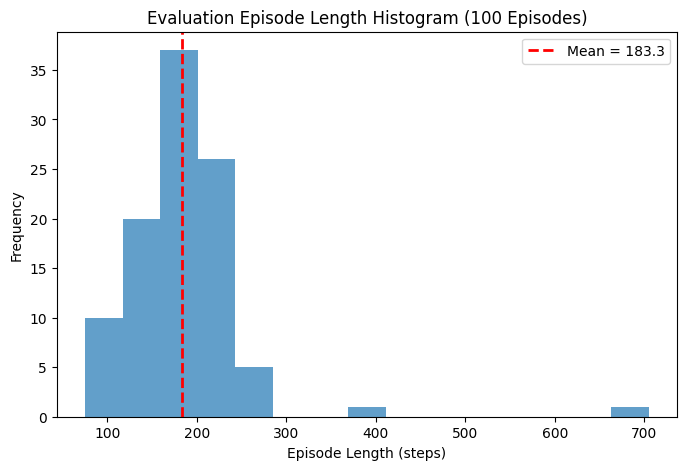

In [50]:
plt.figure(figsize=(8,5))
plt.hist(eval_lengths, bins=15, alpha=0.7)
plt.axvline(mean_length, color='red', linestyle='dashed', linewidth=2,
            label=f"Mean = {mean_length:.1f}")
plt.xlabel("Episode Length (steps)")
plt.ylabel("Frequency")
plt.title("Evaluation Episode Length Histogram (100 Episodes)")
plt.legend()
plt.show()